In [ ]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from cluster.params import * 


## 

Sampling / density / score: 100%|██████████| 4/4 [01:16<00:00, 19.04s/sampler]


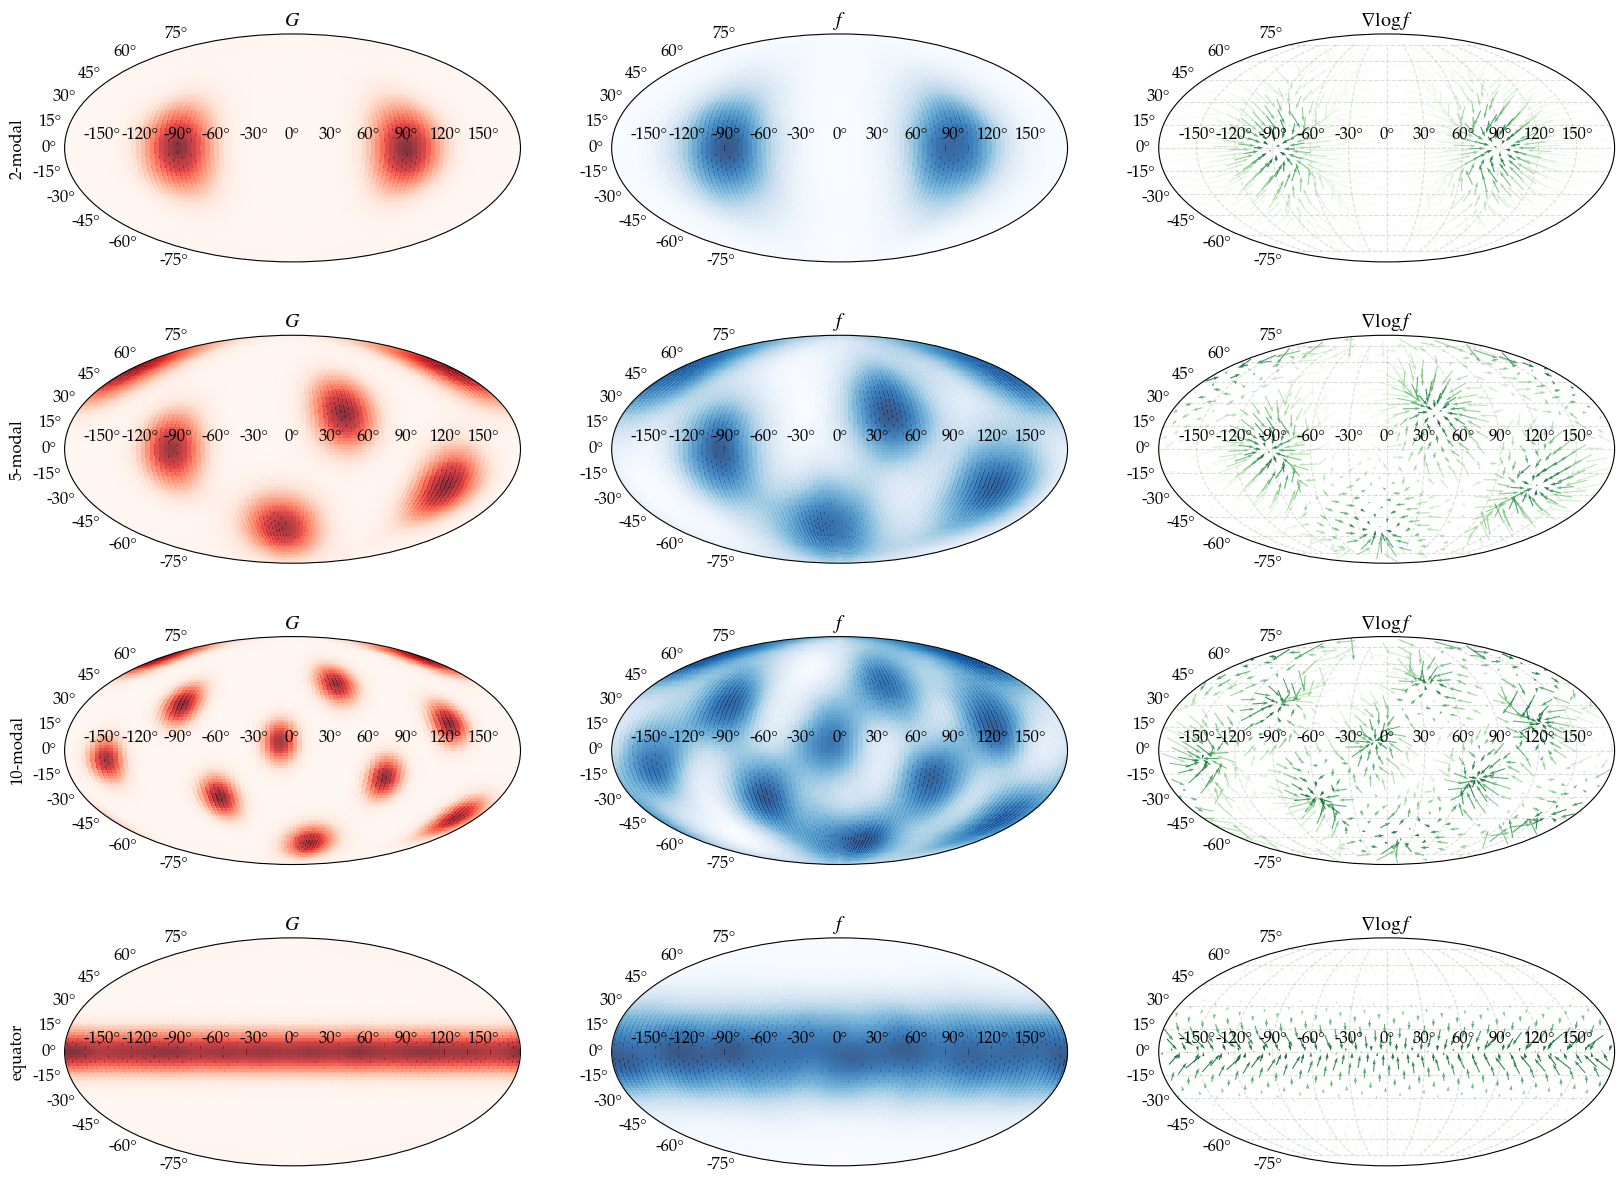

In [95]:
manifold_type = 'S2'; manifold = get_manifold(manifold_type)
G_sampler_ls = getparams(manifold_type)[1]

sigma2 = 0.1
sample_size = 10000
fig, axs = plt.subplots(len(G_sampler_ls), 3, figsize=(20, 15),  
                         subplot_kw={'projection': 'mollweide'}
)
axs  = axs.T
for idx in tqdm(
    range(len(G_sampler_ls)),
    total=len(G_sampler_ls),
    desc="Sampling / density / score",
    unit="sampler",
    leave=True,
    dynamic_ncols=True,
):
    G = G_sampler_ls[idx]
    axs[0,idx].set_ylabel(G.name)
    axs[0,idx].set_title(f'$G$')
    axs[1,idx].set_title(f'$f$')
    axs[2, idx].set_title(f'$\\nabla \log f$')
    # fig.colorbar(im_f, ax=axs[1,0], orientation='horizontal', fraction=0.05, pad=0.14)

    Theta = G.sample(sample_size)
    X = manifold.random_riemannian_normal(Theta, 1 / sigma2, sample_size)

    res = 100
    X_grid, grid_theta, grid_phi, = S2grid(res)

    G = kernel_density_estimate(manifold_type, Theta, X_grid, kappa = 40)[1]
    f = kernel_density_estimate(manifold_type, X, X_grid, kappa = 40)[1]

    im_f = axs[0,idx].pcolormesh((grid_phi - np.pi), (np.pi/2 - grid_theta), G.reshape(res, res), alpha=0.8,shading='auto',cmap='Reds')
    im_f = axs[1,idx].pcolormesh((grid_phi - np.pi), (np.pi/2 - grid_theta), f.reshape(res, res), alpha=0.8,shading='auto',cmap='Blues')

    res = 25
    X_grid, grid_theta, grid_phi, = S2grid_fib(res)
    # ------ Oracle score estimation
    oracle_score = []
    for x in X_grid:
        dists = manifold.metric.dist(x, Theta)      # shape (N,)
        logs  = manifold.metric.log(x, Theta)       # shape (N, dim)
        weights = np.exp(-(dists ** 2) / (2 * sigma2))
        oracle_score.append(
            - (1 / sigma2) * (weights[:, None] * logs).sum(axis=0) / weights.sum()
        )

    def kde_s2(x, X):
        n = len(X)
        d = manifold.dim
        bandwidth = (n * (d + 2) / 4) ** (-1 / (d + 4))
        dists = manifold.metric.dist(x, X)
        return np.sum(np.exp(-0.5 * (dists / bandwidth)**2))
    score = np.array(oracle_score)
    S2plot_quiver(X_grid, score, figax=(fig, axs[2, idx]), scale=10, cmap="Greens", cvals = np.array([kde_s2(x, X) for x in X_grid]))
    
plt.savefig('../fig/S2_field.png', bbox_inches='tight')

Sampling / density / score: 100%|██████████| 4/4 [00:08<00:00,  2.16s/sampler]


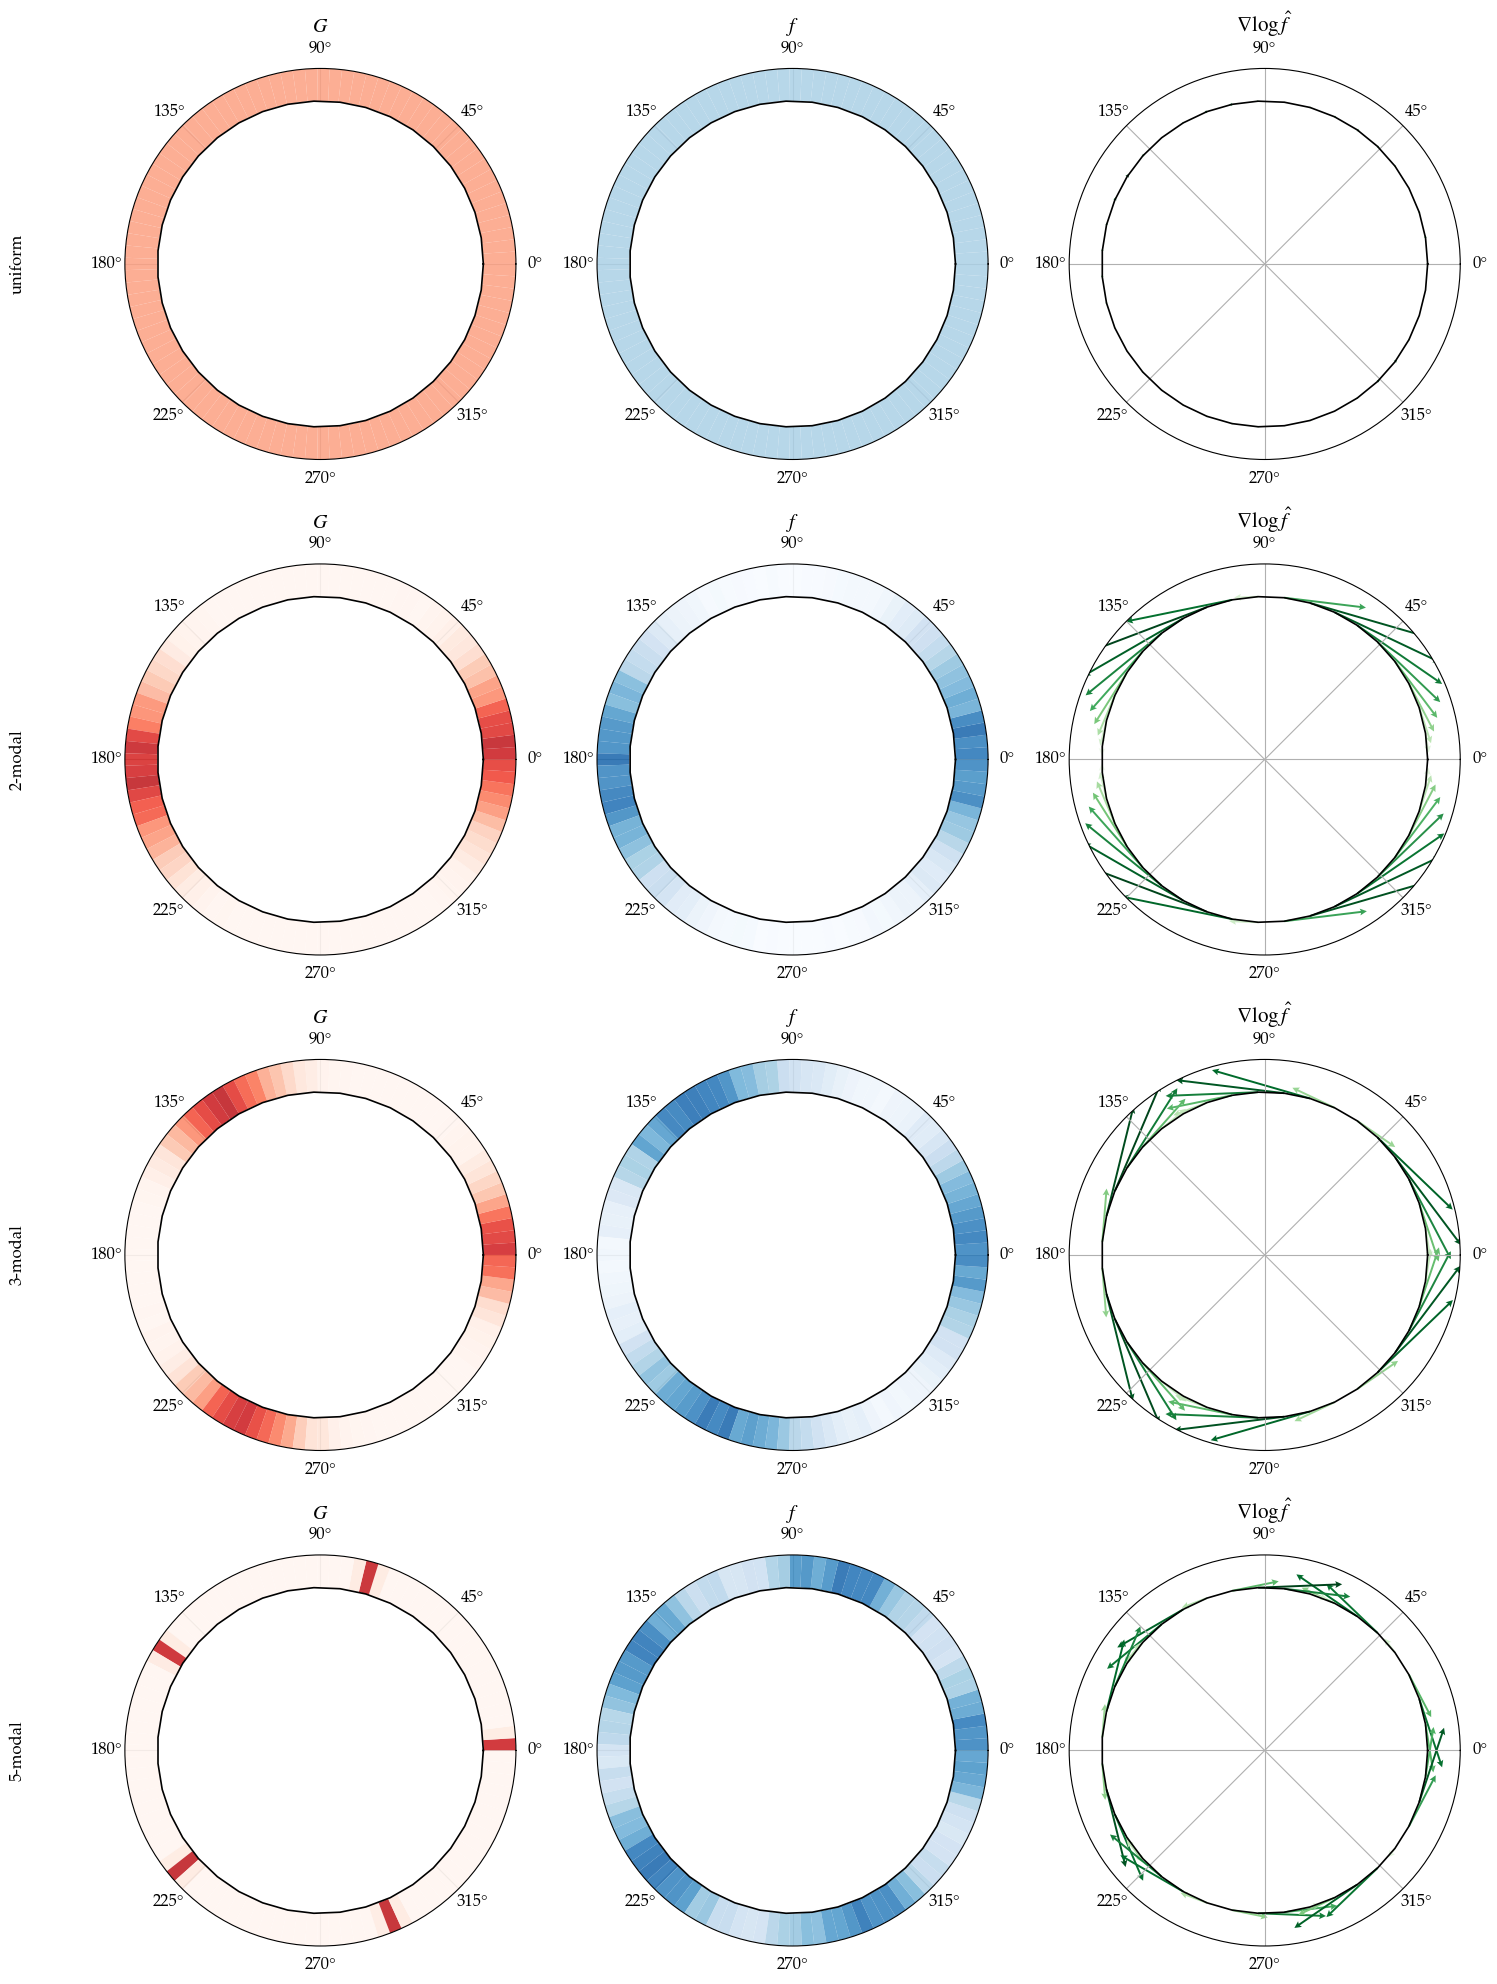

In [94]:
manifold_type = 'S1'; manifold = get_manifold(manifold_type)
G_sampler_ls = getparams(manifold_type)[1]
sigma2 = 0.1
sample_size = 10000

scales = [10, 10, 7, 4]
bottom = .75; top = .9; upperlim = .9
fig, axs = plt.subplots(len(G_sampler_ls), 3, figsize=(15, 20),  subplot_kw={'projection': 'polar'})

for idx in tqdm( range(len(G_sampler_ls)), total=len(G_sampler_ls), desc="Sampling / density / score", unit="sampler", leave=True, dynamic_ncols=True,):
    G = G_sampler_ls[idx]

    # Put the label in axes coordinates (not data coords) so it doesn't get overlaid/rotated weirdly
    axs[idx, 0].set_ylabel("")
    axs[idx, 0].text(
        -0.25, 0.5, G.name,
        transform=axs[idx, 0].transAxes,
        ha="right", va="center",
        rotation=90,
    )
    axs[idx, 0].set_title(f'$G$')
    axs[idx, 1].set_title(f'$f$')
    axs[idx, 2].set_title(f'$\\nabla \log f$')

    Theta = manifold.intrinsic_to_extrinsic_coords(  manifold.extrinsic_to_intrinsic_coords(G.sample(sample_size)) - np.pi / 12)
    X = manifold.random_riemannian_normal(Theta, 1 / sigma2, sample_size)

    grid_size  = 100; 
    grid_I = np.linspace(0, 2*np.pi, grid_size)
    for ax, data,cmap in zip(axs[idx, :], [Theta, X], ['Reds','Blues']):
        bin_centers = uniform_points(manifold_type, grid_size)          
        dists_all = np.array([ manifold.metric.dist(g, bin_centers) for g in data])        
        labels = np.argmin(dists_all, axis=1)                      
        hat_f = np.bincount(labels, minlength=grid_size) / len(data); hat_f /= 1.25*np.max(hat_f)
        if G.name == 'uniform': hat_f = np.ones_like(hat_f)/3
        bars = ax.bar(
            grid_I[:-1],
            top - bottom,
            width=np.diff(grid_I),
            bottom=bottom,
            color=plt.colormaps[cmap](hat_f[:-1]),
            alpha=0.85,
            edgecolor='none',
            align='edge',
            zorder=2,
        )
        ax.set_ylim(0, upperlim)
        ax.set_yticks([])
        ax.bar(0, bottom, width=2 * np.pi, bottom=0, color="white", edgecolor="none", align="edge", zorder=3,)


    grid_size  = 40; 
    grid_I = np.linspace(0, 2*np.pi, grid_size)
    X_grid = np.stack([np.cos(grid_I), np.sin(grid_I)], axis=1)
    dists_all = np.array([ manifold.metric.dist(g, X_grid) for g in X])        
    labels = np.argmin(dists_all, axis=1)                      
    hat_f = np.bincount(labels, minlength=grid_size) / len(data)

    # ------ Score estimation using bin centers (unchanged)
    oracle_score = []
    for x in X_grid:
        dists = manifold.metric.dist(x, X_grid)
        logs  = manifold.metric.log(x, X_grid)
        weights = hat_f * np.exp(-(dists**2) / (2 * sigma2))
        v = -(1 / sigma2) * (weights[:, None] * logs).sum(axis=0) / weights.sum()
        v_tan = v - np.dot(v, x) * x
        oracle_score.append(v_tan)

    oracle_score = np.array(oracle_score)

    # ---------- SCORE ---------------------------------------------------------------------------
    axs[idx, 2].quiver(
        grid_I,                         
        np.ones_like(grid_I)*bottom,    
        oracle_score[:, 0],          
        oracle_score[:, 1],          
        np.linalg.norm(oracle_score, axis=1),                 
        scale=scales[idx],           
        width=0.005,         
        headwidth=3.5,        
        headlength=3.5,       
        headaxislength=3, 
        cmap='Greens',       
        alpha=1,         
        edgecolors=None,     
        linewidths=0.25,   
    )
    axs[idx, 2].set_title('$\\nabla \log \hat f$', fontsize=15)
    for ax in axs[idx, :]:
        ax.set_ylim(0, upperlim)  
        ax.set_yticks([])
        ax.plot(grid_I, bottom*np.ones_like(grid_I), color='black', linewidth=1.2, zorder=4)
plt.tight_layout()
plt.savefig('../fig/S1_field.png', bbox_inches='tight')